<a href="https://colab.research.google.com/github/cnsalsabila/myXLSentimentAnalysis/blob/main/Week%202-3/Scrap_Review_myXL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install google_play_scraper
!pip install textblob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re                           # access to %%time, for timing individual notebook cells

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (15,10)

In [13]:
#Android App NHS link from Google Play at
#https://play.google.com/store/apps/details?id=com.apps.MyXL&pcampaignid=web_share
#The apps ID found in the link after id=com.apps.MyXL
#The apps name on Google Play titled: NHS COVID-19 Department of Health and Social Care, UK Government
#Dated 17 April 2022: number of reviews 134,397

from google_play_scraper import app, Sort, reviews_all

nhs_reviews = reviews_all(
    'com.apps.MyXL',
    sleep_milliseconds=0, # defaults to 0
    lang='id', # defaults to 'en'
    country='id',
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [19]:
#Save the NHS Apps reviews into dataframe
df_myxl_rev = pd.DataFrame(np.array(nhs_reviews),columns=['content'])
df_myxl_rev = df_myxl_rev.join(pd.DataFrame(df_myxl_rev.pop('content').tolist()))
df_myxl_rev.to_csv('df_myxl_rev.csv', index=False)
df_myxl_rev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e0e9a83b-9560-418c-8912-90a8bb95fcd6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah di downlod kok gak bisa di buka,2,0,None,2026-04-02 13:05:10,"Hi Kak, Maya mohon maaf ya atas kendalanya, yu...",2026-04-02 15:01:10,None
1,040abecc-bdce-4fee-b622-c88498925882,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Jaringan sudah gak lemot lumayan tapi harga ku...,3,0,8.10.0,2026-04-02 13:04:22,"Hi Kak, Maya akan senang membantu menyelesaika...",2026-04-02 15:01:14,8.10.0
2,a58f4ca3-9a90-4677-a2c6-9ada437b6efa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mimtak tolong kepda admin . kenapa setelah dou...,1,0,9.1.0,2026-04-02 13:03:20,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-04-02 15:01:15,9.1.0
3,84d5458e-e1dc-4941-aacf-69749354d86f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sinyal nya jelek banget mending hpus aja dari ...,1,0,9.1.0,2026-04-02 13:03:12,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-04-02 15:01:17,9.1.0
4,2bdd2b04-a840-494a-99ce-94f8b49c8f8a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gk usah ngeklaim 5g tercepat di indonesia kalo...,1,0,9.1.0,2026-04-02 12:58:35,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-04-02 13:00:10,9.1.0


In [20]:
print(df_myxl_rev.reviewCreatedVersion.unique())
print(df_myxl_rev.reviewCreatedVersion.nunique())

[None '8.10.0' '9.1.0' '8.9.1' '9.0.0' '8.4.0' '8.7.0' '7.7.1' '5.6.2'
 '8.6.0' '8.0.0' '5.6.15' '7.11.0' '7.10.0' '8.3.0' '7.0.0' '7.1.1'
 '8.2.0' '6.5.2' '7.8.1' '7.2.0' '8.1.0' '5.6.13' '5.8.5' '8.8.0' '5.3.10'
 '5.7.10' '5.8.8' '5.6.11' '8.9.0' '5.6.12' '6.1.0' '7.4.0' '6.4.2'
 '8.5.0' '6.4.1' '7.6.0' '7.5.1' '5.1.4' '5.6.4' '7.9.1' '6.3.0' '3.8.6'
 '5.7.3' '5.6.10' '5.5.4' '5.5.0' '5.8.1' '5.8.4' '6.0.2' '5.3.4' '5.5.10'
 '5.7.14' '5.7.2' '5.3.6' '7.3.0' '5.7.6' '5.8.3' '5.8.0' '7.3.1' '5.6.17'
 '5.5.11' '5.5.17' '3.9.9' '5.8.6' '6.5.0' '5.7.4' '5.3.12' '7.0.3'
 '3.9.11' '7.8.0' '5.6.16' '3.9.5' '7.5.2' '5.7.12' '5.5.15' '6.5.1'
 '5.6.8' '5.6.7' '5.1.5' '5.7.9' '5.2.5' '5.6.6' '5.5.9' '5.6.1' '5.7.1'
 '6.2.0' '5.5.6' '5.6.3' '5.5.16' '7.1.0' '5.5.13' '6.0.1' '3.9.8' '5.7.5'
 '5.3.2' '5.5.2' '5.3.5' '3.8.4' '5.5.8' '3.9.6' '5.6.0' '5.6.14' '5.3.0'
 '6.0.0' '2.0.2' '5.3.9' '5.7.8' '5.1.3' '7.0.2' '7.0.1' '5.3.1' '5.3.11'
 '5.1.1' '5.2.4' '7.9.0' '5.1.2' '3.9.4' '3.7.0' '3.6.0' '5.1.

In [21]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_myxl_rev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,udah di downlod kok gak bisa di buka,2,0,None,2026-04-02 13:05:10,"Hi Kak, Maya mohon maaf ya atas kendalanya, yu...",2026-04-02 15:01:10
1,Jaringan sudah gak lemot lumayan tapi harga ku...,3,0,8.10.0,2026-04-02 13:04:22,"Hi Kak, Maya akan senang membantu menyelesaika...",2026-04-02 15:01:14
2,mimtak tolong kepda admin . kenapa setelah dou...,1,0,9.1.0,2026-04-02 13:03:20,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-04-02 15:01:15
3,sinyal nya jelek banget mending hpus aja dari ...,1,0,9.1.0,2026-04-02 13:03:12,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-04-02 15:01:17
4,gk usah ngeklaim 5g tercepat di indonesia kalo...,1,0,9.1.0,2026-04-02 12:58:35,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-04-02 13:00:10
...,...,...,...,...,...,...,...
1004107,Sip dah,3,0,None,2013-02-18 14:25:17,None,NaT
1004108,Operatorku xl,5,0,None,2013-02-11 09:27:57,None,NaT
1004109,Lebih bagus lagi,5,0,1.1.1,2013-02-04 08:49:19,None,NaT
1004110,Bagus,5,0,None,2013-01-31 22:13:48,None,NaT


In [22]:
#Check number of reviews scores
df_myxl_rev['score'].value_counts()

,count
score,
5,404949
1,379115
4,79938
3,70123
2,69987


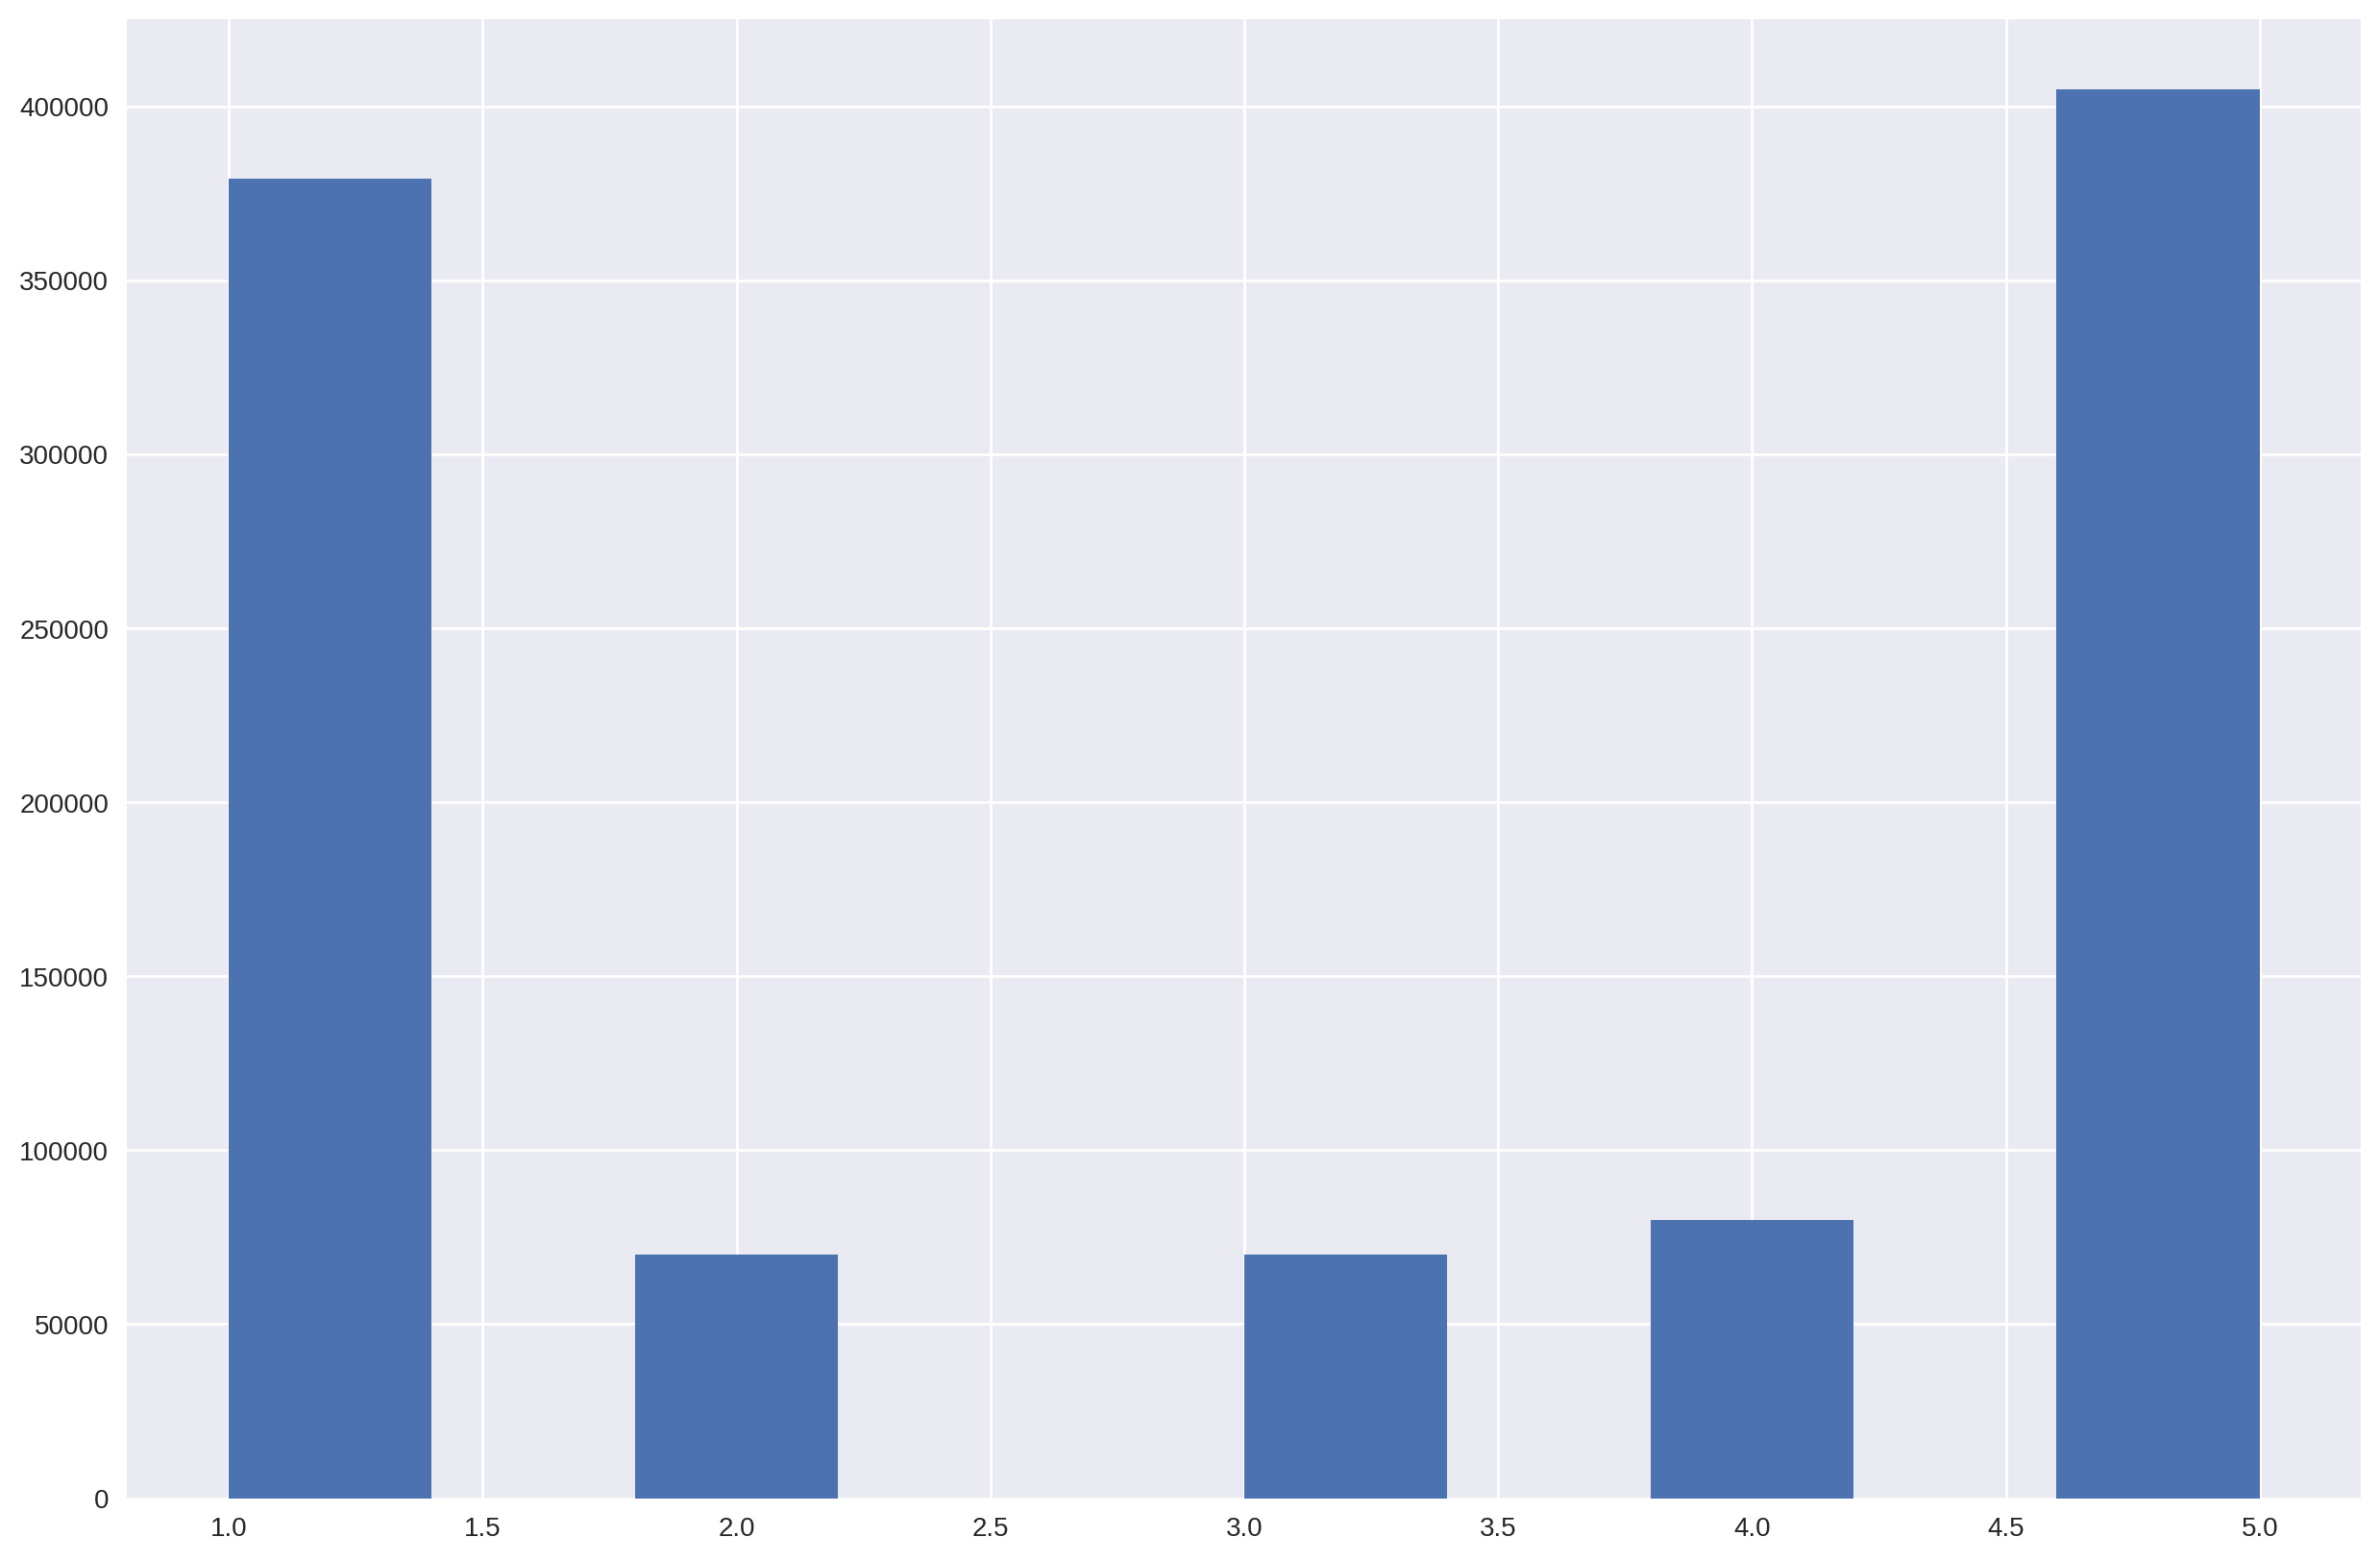

In [23]:
plt.hist(df_myxl_rev['score'])
plt.show()